# Proyecto Final — Manejo de Datos (EDA)
### Ventas Tienda de Tecnología

**Módulo:** Manejo de Datos – EDA
**Grupo:** 04
**Nombre del estudiante:** Katherine Susana Rojas Saborío



## 1. Importación de librerías
Se importan las librerías necesarias para manejo de datos (`pandas`, `numpy`) y visualización (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)


## 2. Carga del archivo CSV
Función para subir/cargar el archivo CSV en Google Colab. Controla el caso de que el archivo no se pueda leer (formato incorrecto, archivo corrupto, etc.).

In [2]:
def cargar_csv():
    try:
        print("Selecciona el archivo CSV...")
        archivo = files.upload()
        nombre = next(iter(archivo))
        df_cargado = pd.read_csv(nombre)
        print(f"\nArchivo cargado. {df_cargado.shape[0]} filas y {df_cargado.shape[1]} columnas.")
        return df_cargado
    except Exception as e:
        print(f"Error al cargar: {e}")
        return None

## 3. Validación de carga previa
Muchas opciones del menú necesitan que el CSV ya esté cargado. Esta función centraliza esa verificación para evitar errores al intentar analizar datos inexistentes.

In [3]:
def datos_disponibles(df_actual):
    if df_actual is None:
        print("Primero debes cargar un archivo CSV (opcion 1 del menú).")
        return False
    return True

## 4. Visualización de la estructura del conjunto de datos
Muestra las primeras y últimas filas, la forma del DataFrame (filas y columnas) y su información general (`info()`).

In [4]:
def mostrar_estructura(df):
    """Muestra primeras/ultimas filas y la forma general del dataset."""
    if not datos_disponibles(df):
        return
    print("Primeras 5 filas:")
    display(df.head())
    print("\nUltimas 5 filas:")
    display(df.tail())
    print(f"\nEl conjunto de datos tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

### 5. Identificación de tipos de datos
Revisa el tipo de dato de cada columna con `df.info()` y `df.dtypes`. Esto permite detectar, por ejemplo, columnas numéricas cargadas como texto.

In [5]:
def analizar_tipos_datos(df):
    """Muestra el tipo de dato de cada columna del dataset."""
    if not datos_disponibles(df):
        return
    print("Informacion general del DataFrame:")
    df.info()
    print("\nTipos de dato por columna:")
    display(pd.DataFrame(df.dtypes, columns=['Tipo de dato']))

## 6. Identificación de valores nulos o faltantes
Según la exploración inicial, `precio_unitario` y `region` tienen valores nulos. Esta función cuantifica los nulos por columna y muestra el porcentaje que representan.

In [6]:
def analizar_nulos(df):
    """Muestra la cantidad y el porcentaje de valores nulos por columna."""
    if not datos_disponibles(df):
        return
    nulos = df.isnull().sum()
    porcentaje = (df.isnull().mean() * 100).round(2)
    resumen = pd.DataFrame({'valores_nulos': nulos, 'porcentaje_%': porcentaje})
    resumen = resumen[resumen['valores_nulos'] > 0].sort_values('valores_nulos', ascending=False)
    if resumen.empty:
        print("No se encontraron valores nulos en el dataset.")
    else:
        print("Columnas con valores nulos:")
        display(resumen)

## 7. Identificación de datos duplicados
Busca filas completamente duplicadas (mismo valor en todas las columnas) y las muestra.

In [7]:
def analizar_duplicados(df):
    """Identifica filas duplicadas dentro del dataset."""
    if not datos_disponibles(df):
        return
    duplicados = df.duplicated().sum()
    print(f"Cantidad de filas duplicadas encontradas: {duplicados}")
    if duplicados > 0:
        print("\nEjemplo de filas duplicadas:")
        display(df[df.duplicated(keep=False)].sort_values(by='id_venta').head(10))

## 8. Identificación y tratamiento de datos inconsistentes
En la exploración inicial del CSV se detectaron las siguientes inconsistencias:

- **`categoria`**, **`vendedor`** y **`cliente_frecuente`**: mismos valores escritos con distinta combinación de mayúsculas/minúsculas y espacios en blanco (ej. `"Accesorios"`, `"accesorios"`, `" Accesorios"`).
- **`producto`**: mismo producto escrito de forma diferente (con/sin tildes, con/sin comillas), por ejemplo `"Audífonos inalámbricos"` vs `"Audifonos inalambricos"`.
- **`fecha`**: mezcla de formatos (`AAAA-MM-DD` y `DD/MM/AAAA`).
- **`cliente_frecuente`**: valores `"Sí"/"Si"/"si"/"SI"` y `"No"/"no"/"NO"` mezclados.
- Filas duplicadas y valores nulos (vistos en las secciones anteriores).

Esta función genera `df_limpio`, una copia estandarizada del dataset que se usará en el resto de los análisis, sin modificar el archivo original.

In [8]:
def limpiar_datos(df):
    """Genera una version estandarizada del dataset y muestra un resumen de los cambios."""
    if not datos_disponibles(df): return None
    temp = df.copy()

    print("\n" + "*"*40)
    print("INFORME DE LIMPIEZA DE DATOS")
    print("*"*40)

    # Rastrear datos antes de la limpieza
    filas_antes = temp.shape[0]
    duplicados_antes = temp.duplicated().sum()
    nulos_precio_antes = temp['precio_unitario'].isnull().sum() if 'precio_unitario' in temp.columns else 0
    nulos_region_antes = temp['region'].isnull().sum() if 'region' in temp.columns else 0

    # 1. Eliminar ventas no completadas (precio nulo)
    if 'precio_unitario' in temp.columns:
        temp = temp.dropna(subset=['precio_unitario'])

    # 2. Estandarización de texto
    for columna in ['categoria', 'vendedor', 'producto', 'region', 'metodo_pago']:
        if columna in temp.columns:
            temp[columna] = temp[columna].astype(str).str.strip()
            if columna != 'metodo_pago':
                temp[columna] = temp[columna].str.title()

    # 3. Normalizar tildes y comillas en producto
    reemplazos = {'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u', '"': '', "'": ''}
    def normalizar_producto(texto):
        t = str(texto).lower()
        for k, v in reemplazos.items():
            t = t.replace(k, v)
        return t.strip().title()

    if 'producto' in temp.columns:
        temp['producto_normalizado'] = temp['producto'].apply(normalizar_producto)

    # 4. Estandarizar cliente_frecuente
    if 'cliente_frecuente' in temp.columns:
        temp['cliente_frecuente'] = temp['cliente_frecuente'].astype(str).str.strip().str.lower()
        temp['cliente_frecuente'] = temp['cliente_frecuente'].replace({'si': 'Si', 'sí': 'Si', 'no': 'No'})

    # 5. Formato de fechas
    if 'fecha' in temp.columns:
        temp['fecha'] = pd.to_datetime(temp['fecha'], format='mixed', dayfirst=False, errors='coerce')

    # 6. Tratamiento de nulos restantes
    if 'region' in temp.columns:
        temp['region'] = temp['region'].replace('Nan', 'Sin dato').fillna('Sin dato')

    # 7. Eliminar duplicados
    temp = temp.drop_duplicates()
    duplicados_despues = temp.duplicated().sum()
    filas_despues = temp.shape[0]

    # REPORTE
    print(f"[*] Filas iniciales: {filas_antes} | Filas finales (limpias): {filas_despues}")
    print(f"[*] Ventas no completadas (sin precio): Se eliminaron {nulos_precio_antes} registros.")
    print(f"[*] Filas duplicadas: Habian {duplicados_antes} | Quedan {duplicados_despues} (Se eliminaron {duplicados_antes - duplicados_despues})")
    print(f"[*] Valores nulos en 'region' ajustados: {nulos_region_antes} (se marcaron como 'Sin dato')")
    print("[*] Texto: Se unificaron mayusculas/minusculas y se eliminaron espacios extra.")
    print("[*] Productos: Se eliminaron tildes/comillas para evitar productos duplicados.")
    print("[*] Clientes: Se estandarizaron las respuestas a 'Si' o 'No'.")
    print("*" * 40 + "\n")

    return temp

def analisis_adicional(df):
    """Ejecuta la limpieza de datos y un analisis extra sobre clientes frecuentes."""
    print("Iniciando proceso de estandarización...")
    df_limpio = limpiar_datos(df)

    if df_limpio is None:
        return None

    print("\nComparacion clientes frecuentes vs no frecuentes:")
    base = df_limpio.copy()
    base['total_venta'] = base['cantidad'] * base['precio_unitario']
    display(base.groupby('cliente_frecuente')['total_venta'].agg(['count', 'mean', 'sum']).round(2))

    return df_limpio

### 9. Estadísticas descriptivas
Calcula las estadísticas descriptivas (media, mediana, desviación estándar, mínimo, máximo, cuartiles) de las variables numéricas, y un resumen de frecuencias para las variables categóricas.

In [9]:
def estadisticas_descriptivas(df_activo):
    """Muestra estadisticas descriptivas, cuartiles y deteccion de outliers."""
    if not datos_disponibles(df_activo): return

    print("Estadisticas descriptivas generales (pandas):")
    cols_num = ['cantidad', 'precio_unitario']
    cols_presentes = [c for c in cols_num if c in df_activo.columns]

    if cols_presentes:
        display(df_activo[cols_presentes].describe().round(2))

        print("\n" + "="*45)
        print("ANALISIS DE CUARTILES Y LIMITES (OUTLIERS)")
        print("="*45)

        for col in cols_presentes:
            Q1 = df_activo[col].quantile(0.25)
            Q3 = df_activo[col].quantile(0.75)
            IQR = Q3 - Q1
            limite_inf = Q1 - 1.5 * IQR
            limite_sup = Q3 + 1.5 * IQR

            # Contar outliers
            outliers = df_activo[(df_activo[col] < limite_inf) | (df_activo[col] > limite_sup)]
            cant_outliers = outliers.shape[0]

            print(f"\n-> Variable: {col.upper()}")
            print(f"   Q1 (25%): {Q1:.2f} | Q3 (75%): {Q3:.2f}")
            print(f"   Limite Inferior: {limite_inf:.2f} | Limite Superior: {limite_sup:.2f}")

            if cant_outliers > 0:
                print(f"   [!] ALERTA: Se detectaron {cant_outliers} registros fuera de los limites (posibles outliers).")
            else:
                print("   [v] No se detectaron outliers fuera de los limites calculados.")
        print("="*45 + "\n")

    if 'categoria' in df_activo.columns:
        print("\nFrecuencia de categorias:")
        display(df_activo['categoria'].value_counts())

    if 'metodo_pago' in df_activo.columns:
        print("\nFrecuencia por metodo de pago:")
        display(df_activo['metodo_pago'].value_counts())

## 10. Filtrar o consultar datos
Permite al usuario filtrar las ventas por categoría de producto o por región, para explorar subconjuntos específicos de los datos.

In [10]:
def filtrar_datos(df_limpio):
    """Filtra y consulta los datos por categoría o región usando selección numérica."""
    if df_limpio is None:
        return

    print("\n" + "*"*40)
    print("CONSULTA Y FILTRADO DE DATOS")
    print("*"*40)
    print("1. Filtrar por Categoría")
    print("2. Filtrar por Región")
    print("3. Cancelar")
    print("*"*40)

    opcion = input("Elige una opción de filtrado (1-3): ").strip()

    if opcion == '1':
        categorias = sorted(df_limpio['categoria'].dropna().unique())
        print("\n--- Categorías disponibles ---")
        for i, cat in enumerate(categorias, 1):
            print(f"{i}. {cat}")

        try:
            sel = int(input("\nDigita el número de la categoría: "))
            if 1 <= sel <= len(categorias):
                cat_elegida = categorias[sel-1]
                filtro = df_limpio[df_limpio['categoria'] == cat_elegida]
                print(f"\n[v] Mostrando resultados para la categoría: {cat_elegida} ({len(filtro)} registros encontrados)")
                display(filtro)
            else:
                print("\n[!] Número fuera de rango. Intenta de nuevo.")
        except ValueError:
            print("\n[!] Error: Debes ingresar un número entero válido.")

    elif opcion == '2':
        regiones = sorted(df_limpio['region'].dropna().unique())
        print("\n--- Regiones disponibles ---")
        for i, reg in enumerate(regiones, 1):
            print(f"{i}. {reg}")

        try:
            sel = int(input("\nDigita el número de la región: "))
            if 1 <= sel <= len(regiones):
                reg_elegida = regiones[sel-1]
                filtro = df_limpio[df_limpio['region'] == reg_elegida]
                print(f"\n[v] Mostrando resultados para la región: {reg_elegida} ({len(filtro)} registros encontrados)")
                display(filtro)
            else:
                print("\n[!] Número fuera de rango. Intenta de nuevo.")
        except ValueError:
            print("\n[!] Error: Debes ingresar un número entero válido.")

    elif opcion == '3':
        print("\n[i] Operación de filtrado cancelada.")
    else:
        print("\n[!] Opción no válida. Por favor, selecciona 1, 2 o 3.")

    print("*"*40 + "\n")

## 11. Agrupaciones y operaciones sobre los datos
Calcula el total vendido (`cantidad * precio_unitario`) agrupado por categoría, por vendedor y por región, para identificar los productos y vendedores con mejor desempeño.

In [11]:
def agrupaciones(df_limpio):
    """Calcula el monto total vendido agrupado por categoria, vendedor y region."""
    if df_limpio is None: return

    base = df_limpio.copy()
    base['total_venta'] = base['cantidad'] * base['precio_unitario']

    print("Total vendido por categoria:")
    display(base.groupby('categoria')['total_venta'].sum().sort_values(ascending=False).round(2))

    print("\nTotal vendido por vendedor:")
    display(base.groupby('vendedor')['total_venta'].sum().sort_values(ascending=False).round(2))

    print("\nTotal vendido por region:")
    display(base.groupby('region')['total_venta'].sum().sort_values(ascending=False).round(2))

    print("\nCantidad promedio de unidades vendidas por metodo de pago:")
    display(base.groupby('metodo_pago')['cantidad'].mean().round(2))

## 12. Análisis de relaciones entre variables
Explora si existe relación entre el precio unitario y la cantidad comprada, y calcula la correlación entre las variables numéricas.

In [12]:
def analisis_relaciones(df_activo):
    """Analiza la relacion entre cantidad y precio unitario mediante correlacion."""
    if df_activo is None: return

    correlacion = df_activo[['cantidad', 'precio_unitario']].corr()
    print("Matriz de correlacion entre cantidad y precio_unitario:")
    display(correlacion)

    valor = correlacion.loc['cantidad', 'precio_unitario']
    print(f"\nCorrelacion cantidad vs precio_unitario: {valor:.3f}")
    if abs(valor) < 0.1:
        print("La correlacion es practicamente nula: no hay relacion lineal clara entre ambas variables.")
    elif valor > 0:
        print("Existe una relacion positiva debil/moderada entre ambas variables.")
    else:
        print("Existe una relacion negativa debil/moderada entre ambas variables.")

## 13. Representaciones gráficas
Genera un conjunto de gráficos para visualizar los hallazgos principales: distribución de ventas por categoría, ventas totales por región, evolución de ventas en el tiempo y distribución del precio unitario.

In [13]:
def generar_graficos(df_limpio):
    if df_limpio is None:
        return

    base = df_limpio.copy()
    base['total_venta'] = base['cantidad'] * base['precio_unitario']

    colores_olivo = ['#606C38', '#283618', '#84A98C', '#52796F', '#354F52']
    color_fondo_interno = '#E4E9F0'

    def aplicar_estilo_grafico(fig, ax):
        fig.patch.set_facecolor('white')
        ax.set_facecolor(color_fondo_interno)

    # Gráfico: Cantidad de ventas por categoría
    fig, ax = plt.subplots(figsize=(9, 5))
    aplicar_estilo_grafico(fig, ax)

    counts = base['categoria'].value_counts()
    bars = counts.plot(kind='bar', color=colores_olivo[2], edgecolor='#354F52', ax=ax)

    for bar in bars.patches:
        height = bar.get_height()
        ax.annotate(f'{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#283618')

    plt.title('Cantidad de Ventas por Categoría', fontweight='bold', loc='center', fontsize=13, pad=15)
    plt.xlabel('Categoría', fontstyle='italic')
    plt.ylabel('Cantidad de Ventas')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

    # Gráfico: Total vendido por región
    fig, ax = plt.subplots(figsize=(9, 5))
    aplicar_estilo_grafico(fig, ax)

    totales_region = base.groupby('region')['total_venta'].sum().sort_values(ascending=False)
    bars = totales_region.plot(kind='bar', color=colores_olivo[0], edgecolor='#354F52', ax=ax)

    ax.ticklabel_format(style='plain', axis='y')
    ax.yaxis.set_major_formatter('₡{x:,.0f}')

    for bar in bars.patches:
        height = bar.get_height()
        ax.annotate(f'₡{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#283618')

    plt.title('Total Vendido por Región', fontweight='bold', loc='center', fontsize=13, pad=15)
    plt.xlabel('Región', fontstyle='italic')
    plt.ylabel('Total Vendido (₡)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

    # Gráfico: Evolución mensual del total vendido
    ventas_por_fecha = base.dropna(subset=['fecha']).groupby(base['fecha'].dt.to_period('M'))['total_venta'].sum()

    fig, ax = plt.subplots(figsize=(10, 5))
    aplicar_estilo_grafico(fig, ax)

    meses_labels = [p.strftime('%b') for p in ventas_por_fecha.index]

    ax.plot(range(len(ventas_por_fecha)), ventas_por_fecha.values, marker='o', color=colores_olivo[3], linewidth=2, markersize=6)
    ax.set_xticks(range(len(ventas_por_fecha)))
    ax.set_xticklabels(meses_labels, rotation=0)

    ax.ticklabel_format(style='plain', axis='y')
    ax.yaxis.set_major_formatter('₡{x:,.0f}')

    for x, y in enumerate(ventas_por_fecha.values):
        ax.annotate(f'₡{y:,.0f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8, fontweight='bold', color='#283618')

    plt.title('Evolución Mensual del Total Vendido', fontweight='bold', loc='center', fontsize=13, pad=15)
    plt.xlabel('Mes', fontstyle='italic')
    plt.ylabel('Total Vendido (₡)')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

    # Gráfico: Distribución de métodos de pago
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor('white')

    pago_counts = base['metodo_pago'].value_counts()
    total_pedidos = pago_counts.sum()

    def func_etiqueta(pct):
        val = int(round(pct * total_pedidos / 100.0))
        return f'{pct:.1f}%\n({val} ped.)'

    pago_counts.plot(kind='pie', autopct=func_etiqueta, colors=colores_olivo, startangle=140,
                     wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 10, 'weight': 'bold', 'color': '#283618'}, ax=ax)

    plt.title('Distribución de Métodos de Pago', fontweight='bold', loc='center', fontsize=13, pad=15)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*50 + "\n")

    # Gráfico: Boxplot de outliers
    col_data = base['total_venta']
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = max(0, Q1 - 1.5 * IQR)
    lim_sup = Q3 + 1.5 * IQR

    fig, ax = plt.subplots(figsize=(10, 5))
    aplicar_estilo_grafico(fig, ax)

    sns.boxplot(x=col_data, ax=ax, color=colores_olivo[2], fliersize=6, linewidth=1.5,
                flierprops={'marker': 'o', 'markerfacecolor': colores_olivo[3], 'markeredgecolor': '#283618'})

    ax.ticklabel_format(style='plain', axis='x')

    ax.axvline(Q1, color='#283618', linestyle='--', linewidth=1.5, label=f'Q1 = {Q1:,.1f}')
    ax.axvline(Q3, color='#283618', linestyle='--', linewidth=1.5, label=f'Q3 = {Q3:,.1f}')
    ax.axvline(lim_inf, color='#52796F', linestyle=':', linewidth=1.5, label=f'Límite Inf. = {lim_inf:,.1f}')
    ax.axvline(lim_sup, color='#52796F', linestyle=':', linewidth=1.5, label=f'Límite Sup. = {lim_sup:,.1f}')

    ax.set_title('Distribución de Montos por Pedido (Análisis de Outliers)', fontweight='bold', loc='center', fontsize=13, pad=15)
    ax.set_xlabel('Monto Total por Pedido (₡)', fontstyle='italic')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()

    # Gráfico: comportamiento por tipo de cliente
    resumen_clientes = base.groupby('cliente_frecuente').agg(
        cantidad_promedio=('cantidad', 'mean'),
        monto_promedio=('total_venta', 'mean')
    ).round(2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('white')

    # Panel 1: Cantidad promedio
    axes[0].set_facecolor(color_fondo_interno)
    resumen_clientes['cantidad_promedio'].plot(kind='bar', ax=axes[0], color=colores_olivo[0], edgecolor='#354F52', width=0.5)
    axes[0].set_title('Cantidad Promedio de Artículos', fontweight='bold', fontsize=11, pad=10)
    axes[0].set_xlabel('¿Cliente Frecuente?', fontstyle='italic')
    axes[0].set_ylabel('Promedio de Unidades')
    axes[0].set_xticklabels(resumen_clientes.index, rotation=0)

    for p in axes[0].patches:
        axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         xytext=(0, 4), textcoords="offset points",
                         ha='center', va='bottom', fontsize=9, fontweight='bold', color='#283618')

    # Panel 2: Monto promedio
    axes[1].set_facecolor(color_fondo_interno)
    resumen_clientes['monto_promedio'].plot(kind='bar', ax=axes[1], color=colores_olivo[1], edgecolor='#354F52', width=0.5)
    axes[1].set_title('Monto Promedio por Transacción (₡)', fontweight='bold', fontsize=11, pad=10)
    axes[1].set_xlabel('¿Cliente Frecuente?', fontstyle='italic')
    axes[1].set_ylabel('Monto Promedio (₡)')
    axes[1].set_xticklabels(resumen_clientes.index, rotation=0)
    axes[1].ticklabel_format(style='plain', axis='y')
    axes[1].yaxis.set_major_formatter('₡{x:,.0f}')

    for p in axes[1].patches:
        axes[1].annotate(f'₡{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         xytext=(0, 4), textcoords="offset points",
                         ha='center', va='bottom', fontsize=8, fontweight='bold', color='#283618')

    plt.suptitle('Comportamiento de Compra: Clientes Frecuentes vs Ocasionales', fontweight='bold', fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

## 14. Análisis adicional
Realiza un resumen del dataset limpio y las implicaciones del negocio.

In [14]:
def resumen_ejecutivo_negocio(df_limpio):
    """Genera un resumen  con metricas comparativas calculadas sobre los datos limpios."""
    if df_limpio is None:
        return

    base = df_limpio.copy()
    base['total_venta'] = base['cantidad'] * base['precio_unitario']

    total_transacciones = len(base)
    facturacion_total = base['total_venta'].sum()
    ticket_promedio = base['total_venta'].mean()
    ticket_mediana = base['total_venta'].median()
    desviacion = base['total_venta'].std()
    coef_variacion = (desviacion / ticket_promedio) * 100

    ventas_categoria = base.groupby('categoria')['total_venta'].sum().sort_values(ascending=False)
    top_categoria = ventas_categoria.index[0]
    peso_top_categoria = (ventas_categoria.iloc[0] / facturacion_total) * 100
    segunda_categoria = ventas_categoria.index[1]
    peso_segunda_categoria = (ventas_categoria.iloc[1] / facturacion_total) * 100

    ventas_region = base.groupby('region')['total_venta'].sum().sort_values(ascending=False)
    top_region = ventas_region.index[0]
    peso_top_region = (ventas_region.iloc[0] / facturacion_total) * 100
    ultima_region = ventas_region.index[-1]
    brecha_regional = ((ventas_region.iloc[0] - ventas_region.iloc[-1]) / ventas_region.iloc[-1]) * 100

    ventas_vendedor = base.groupby('vendedor')['total_venta'].sum().sort_values(ascending=False)
    top_vendedor = ventas_vendedor.index[0]
    peso_top_vendedor = (ventas_vendedor.iloc[0] / facturacion_total) * 100

    pago_counts = base['metodo_pago'].value_counts(normalize=True) * 100
    top_pago = pago_counts.index[0]
    peso_top_pago = pago_counts.iloc[0]

    ventas_mensuales = base.dropna(subset=['fecha']).groupby(base['fecha'].dt.to_period('M'))['total_venta'].sum()
    mejor_mes = ventas_mensuales.idxmax()
    peor_mes = ventas_mensuales.idxmin()
    variacion_meses = ((ventas_mensuales.max() - ventas_mensuales.min()) / ventas_mensuales.min()) * 100

    resumen_cliente = base.groupby('cliente_frecuente')['total_venta'].agg(['count', 'mean'])
    if 'Si' in resumen_cliente.index and 'No' in resumen_cliente.index:
        ticket_frecuente = resumen_cliente.loc['Si', 'mean']
        ticket_no_frecuente = resumen_cliente.loc['No', 'mean']
        diferencia_ticket = ((ticket_frecuente - ticket_no_frecuente) / ticket_no_frecuente) * 100
        pct_transacciones_frecuentes = (resumen_cliente.loc['Si', 'count'] / total_transacciones) * 100
    else:
        diferencia_ticket = None

    print("\n" + "*" * 60)
    print("           ANÁLISIS DE NEGOCIO          ")
    print("*" * 60)
    print(f"[*] Total de transacciones válidas analizadas: {total_transacciones:,}")
    print(f"[*] Facturación total acumulada: ₡{facturacion_total:,.2f}")
    print(f"[*] Ticket promedio: ₡{ticket_promedio:,.2f}  |  Ticket mediana: ₡{ticket_mediana:,.2f}")
    print(f"[*] Coeficiente de variación del ticket: {coef_variacion:.1f}%")
    print(f"[*] Categoría líder: {top_categoria} ({peso_top_categoria:.1f}% de la facturación)")
    print(f"[*] Región líder: {top_region} ({peso_top_region:.1f}% de la facturación)")
    print(f"[*] Vendedor líder: {top_vendedor} ({peso_top_vendedor:.1f}% de la facturación)")
    print(f"[*] Método de pago preferido: {top_pago} ({peso_top_pago:.1f}% de las transacciones)")
    print("-" * 60)
    print("LECTURA COMPARATIVA DE LOS DATOS:")

    print(f"  - {top_categoria} supera a {segunda_categoria} por "
          f"{peso_top_categoria - peso_segunda_categoria:.1f} puntos porcentuales "
          f"({peso_top_categoria:.1f}% vs {peso_segunda_categoria:.1f}%).")

    print(f"  - {top_region} factura {brecha_regional:.1f}% más que {ultima_region}, "
          f"la región de menor desempeño.")

    print(f"  - El ticket promedio se dispersa {coef_variacion:.1f}% respecto a su media "
          f"({'alta variabilidad entre compras' if coef_variacion > 50 else 'variabilidad moderada entre compras'}).")

    print(f"  - {mejor_mes.strftime('%b %Y')} fue el mes de mayor facturación y "
          f"{peor_mes.strftime('%b %Y')} el de menor, una diferencia de {variacion_meses:.1f}%.")

    if diferencia_ticket is not None:
        signo = "mayor" if diferencia_ticket > 0 else "menor"
        print(f"  - Los clientes frecuentes representan el {pct_transacciones_frecuentes:.1f}% de las "
              f"transacciones y su ticket promedio es {abs(diferencia_ticket):.1f}% {signo} "
              f"que el de clientes no frecuentes.")

    print("*" * 60 + "\n")

## 15. Submenú: Ingreso de nuevos datos
Permite ingresar registros manualmente, siguiendo la misma estructura de columnas del CSV original. Valida el tipo de dato en `cantidad` y `precio_unitario`, y permite guardar los registros ingresados en un nuevo archivo CSV.

In [15]:
def seleccionar_de_lista(titulo, opciones):
    """Muestra una lista numerada y devuelve la opción elegida por el usuario."""
    print(f"\n--- Seleccione {titulo} ---")
    for i, opcion in enumerate(opciones, 1):
        print(f"{i}. {opcion}")

    while True:
        try:
            eleccion = int(input("Digite el número de su opción: "))
            if 1 <= eleccion <= len(opciones):
                return opciones[eleccion - 1]
            else:
                print("Número fuera de rango. Intente de nuevo.")
        except ValueError:
            print("Error: Debe ingresar un número entero válido.")


def submenu_ingreso(nuevos_registros, df):
    """Submenú para ingresar, mostrar y guardar nuevos registros manualmente."""
    while True:
        print("\n" + "*"*40)
        print("SUBMENÚ: INGRESO DE DATOS")
        print("*"*40)
        print("1. Ingresar un nuevo registro")
        print("2. Mostrar registros ingresados")
        print("3. Guardar los nuevos datos")
        print("4. Regresar al menú principal")
        print("*"*40)
        opcion = input("Elige una opción: ").strip()

        if opcion == '1':
            ingresar_registro(nuevos_registros, df)
        elif opcion == '2':
            mostrar_registros_ingresados(nuevos_registros)
        elif opcion == '3':
            guardar_nuevos_datos(nuevos_registros)
        elif opcion == '4':
            break
        else:
            print("Opción no válida, intenta de nuevo.")


def ingresar_registro(nuevos_registros, df):
    """Solicita los datos guiando al usuario mediante listas numéricas."""
    print("\n" + "*"*40)
    print("REGISTRAR NUEVA VENTA")
    print("*"*40)

    try:
        id_venta = int(input("id_venta (número entero): "))
        fecha = input("fecha (AAAA-MM-DD): ").strip()
        producto = input("producto (nombre del artículo): ").strip().title()

        # Obtener listas dinámicas del DataFrame si existe, sino usar valores estándar
        if df is not None:
            categorias = sorted(df['categoria'].dropna().astype(str).str.strip().str.title().unique())
            vendedores = sorted(df['vendedor'].dropna().astype(str).str.strip().str.title().unique())
            regiones = sorted(df['region'].dropna().astype(str).str.strip().str.title().unique())
            metodos = sorted(df['metodo_pago'].dropna().astype(str).str.strip().str.title().unique())
        else:
            categorias = ['Accesorios', 'Audio', 'Celulares', 'Laptops', 'Monitores']
            vendedores = ['Ana Rojas', 'Fabiola Araya', 'Kevin Solano', 'Luis Chinchilla', 'Marisol Vargas']
            regiones = ['Alajuela', 'Cartago', 'Guanacaste', 'Heredia', 'Limón', 'Puntarenas', 'San José']
            metodos = ['Efectivo', 'Sinpe Móvil', 'Tarjeta', 'Transferencia']

        # Selección mediante números
        categoria = seleccionar_de_lista("la Categoría", categorias)
        vendedor = seleccionar_de_lista("el Vendedor", vendedores)
        region = seleccionar_de_lista("la Región", regiones)
        metodo_pago = seleccionar_de_lista("el Método de Pago", metodos)

        cantidad = int(input("\ncantidad (número entero de unidades): "))
        precio_unitario = float(input("precio_unitario (ej. 12500.50): "))

        # Cliente frecuente con número también para mantener consistencia
        opciones_cliente = ['Si', 'No']
        cliente_frecuente = seleccionar_de_lista("si es Cliente Frecuente", opciones_cliente)

        registro = {
            'id_venta': id_venta, 'fecha': fecha, 'producto': producto,
            'categoria': categoria, 'cantidad': cantidad, 'precio_unitario': precio_unitario,
            'vendedor': vendedor, 'region': region, 'metodo_pago': metodo_pago,
            'cliente_frecuente': cliente_frecuente
        }
        nuevos_registros.append(registro)
        print("\n[v] ¡Registro agregado correctamente a la memoria!")

    except ValueError:
        print("\n[!] Error: Formato incorrecto en ID, cantidad o precio. Registro no guardado.")


def mostrar_registros_ingresados(nuevos_registros):
    """Muestra en una tabla los registros ingresados manualmente."""
    if not nuevos_registros:
        print("\nAún no se ha ingresado ningún registro nuevo.")
        return
    print("\nRegistros ingresados en esta sesión:")
    display(pd.DataFrame(nuevos_registros))


def guardar_nuevos_datos(nuevos_registros):
    """Guarda los registros ingresados manualmente en un archivo CSV nuevo."""
    if not nuevos_registros:
        print("\nNo hay registros nuevos para guardar.")
        return
    nuevo_df = pd.DataFrame(nuevos_registros)
    nombre_archivo = 'nuevos_registros_ventas.csv'
    nuevo_df.to_csv(nombre_archivo, index=False)
    print(f"\n[v] Se guardaron {len(nuevos_registros)} registros en '{nombre_archivo}'.")
    try:
        from google.colab import files
        files.download(nombre_archivo)
    except Exception:
        pass

## README.md

In [16]:
def generar_y_descargar_readme():
    """Genera un archivo README.md con la estructura del proyecto y fuerza su descarga."""
    contenido_md = """# Proyecto Final — Manejo de Datos (EDA)
### Análisis de Ventas - Tienda de Tecnología

**Módulo:** Manejo de Datos – EDA
**Grupo:** 04
**Estudiante:** Katherine Susana Rojas Saborío

---

## 1. Descripción General
Este programa en Python está diseñado para realizar un **Análisis Exploratorio de Datos (EDA)** completo sobre un conjunto de datos de ventas. El sistema implementa un menú interactivo robusto, control de errores, validaciones de estado y visualizaciones gráficas profesionales.

## 2. Arquitectura

* **Paso de argumentos explícitos:** Las funciones reciben los DataFrames (`df` o `df_limpio`) como parámetros para garantizar un código modular, predecible y limpio.
* **Validación de carga previa:** El programa verifica de forma estricta que exista un archivo CSV cargado antes de permitir ejecutar cualquier análisis u operación.
* **Control de errores defensivo:** Manejo de excepciones ante archivos corruptos, textos mal formateados o ingresos numéricos incorrectos por parte del usuario.

## 3. Módulos y Opciones del Menú Principal
1. **Cargar archivo CSV:** Permite subir y cargar la base de datos de manera interactiva mediante `google.colab.files`.
2. **Información general y estructura:** Despliega primeras/últimas filas, dimensiones y tipos de datos de las columnas.
3. **Análisis de nulos y duplicados:** Cuantifica valores faltantes y detecta filas completamente duplicadas.
4. **Estadísticas descriptivas y Outliers:** Calcula media, mediana, cuartiles y utiliza el Rango Intercuartílico (IQR) para detectar registros atípicos.
5. **Limpieza de datos (Análisis adicional):** Ejecuta un pipeline de estandarización profunda (elimina ventas sin precio, corrige mayúsculas/minúsculas, normaliza tildes en productos, unifica formato de fechas, maneja regiones nulas y limpia duplicados) mostrando un informe de cambios detallado.
6. **Consultas y filtrados dinámicos:** Permite aislar subconjuntos de información por categoría o región.
7. **Agrupaciones de negocio:** Calcula totales vendidos por vendedor, región y categoría, además del promedio por método de pago.
8. **Análisis de relaciones:** Evalúa la matriz de correlación entre variables numéricas clave.
9. **Visualización gráfica:** Genera 5 gráficos (categorías, región, evolución mensual, métodos de pago y boxplot de outliers).
10. **Documentación (README):** Genera y descarga automáticamente este archivo Markdown.
11. **Submenú de ingreso manual:** Permite registrar nuevas transacciones guiando al usuario mediante menús numéricos automatizados y exportando los datos a un nuevo CSV.
"""

    # Crear y escribir el archivo Markdown
    nombre_archivo = "README.md"
    with open(nombre_archivo, "w", encoding="utf-8") as f:
        f.write(contenido_md.strip())

    print(f"\n[v] Archivo '{nombre_archivo}' generado exitosamente en el entorno.")

    print("[i] Nota: Puedes descargarlo directamente desde el panel de archivos a la izquierda de tu pantalla en Google Colab.")

## 16. Menú principal
Función que muestra el menú principal y direcciona hacia cada herramienta de análisis. Controla el caso de que el usuario ingrese una opción que no existe en el menú.

In [17]:
def mostrar_menu():
    print("\n" + "=" * 50)
    print("PROYECTO FINAL - ANALISIS DE VENTAS")
    print("=" * 50)
    print("1. Cargar archivo CSV")
    print("2. Mostrar informacion del conjunto de datos")
    print("3. Mostrar primeras y ultimas filas")
    print("4. Analizar tipos de datos")
    print("5. Analizar valores nulos")
    print("6. Analizar datos duplicados")
    print("7. Obtener estadisticas descriptivas")
    print("8. Limpiar datos")
    print("9. Filtrar o consultar datos")
    print("10. Realizar agrupaciones y operaciones")
    print("11. Analizar relaciones entre variables")
    print("12. Generar representaciones graficas")
    print("13. Resumen y análisis adicional (con datos limpios)")
    print("14. Ingresar nuevos datos (submenu)")
    print("15. Descargar README.md")
    print("16. Salir")
    print("=" * 50)

## 17. Programa principal
Ejecuta el ciclo del menú principal. Controla que el usuario no pueda usar las opciones de análisis antes de cargar un archivo, y maneja el caso de que se ingrese una opción inexistente.


PROYECTO FINAL - ANALISIS DE VENTAS
1. Cargar archivo CSV
2. Mostrar informacion del conjunto de datos
3. Mostrar primeras y ultimas filas
4. Analizar tipos de datos
5. Analizar valores nulos
6. Analizar datos duplicados
7. Obtener estadisticas descriptivas
8. Limpiar datos
9. Filtrar o consultar datos
10. Realizar agrupaciones y operaciones
11. Analizar relaciones entre variables
12. Generar representaciones graficas
13. Resumen y análisis adicional (con datos limpios)
14. Ingresar nuevos datos (submenu)
15. Descargar README.md
16. Salir
Elige una opcion: 1
Selecciona el archivo CSV...


Saving ventas_tienda_tecnologia_ampliado.csv to ventas_tienda_tecnologia_ampliado (1).csv

Archivo cargado. 1185 filas y 10 columnas.

PROYECTO FINAL - ANALISIS DE VENTAS
1. Cargar archivo CSV
2. Mostrar informacion del conjunto de datos
3. Mostrar primeras y ultimas filas
4. Analizar tipos de datos
5. Analizar valores nulos
6. Analizar datos duplicados
7. Obtener estadisticas descriptivas
8. Limpiar datos
9. Filtrar o consultar datos
10. Realizar agrupaciones y operaciones
11. Analizar relaciones entre variables
12. Generar representaciones graficas
13. Resumen y análisis adicional (con datos limpios)
14. Ingresar nuevos datos (submenu)
15. Descargar README.md
16. Salir
Elige una opcion: 2
Informacion general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185 entries, 0 to 1184
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_venta           1185 non-null   int64  
 1   fecha    

,Tipo de dato
id_venta,int64
fecha,object
producto,object
categoria,object
cantidad,int64
precio_unitario,float64
vendedor,object
region,object
metodo_pago,object
cliente_frecuente,object



PROYECTO FINAL - ANALISIS DE VENTAS
1. Cargar archivo CSV
2. Mostrar informacion del conjunto de datos
3. Mostrar primeras y ultimas filas
4. Analizar tipos de datos
5. Analizar valores nulos
6. Analizar datos duplicados
7. Obtener estadisticas descriptivas
8. Limpiar datos
9. Filtrar o consultar datos
10. Realizar agrupaciones y operaciones
11. Analizar relaciones entre variables
12. Generar representaciones graficas
13. Resumen y análisis adicional (con datos limpios)
14. Ingresar nuevos datos (submenu)
15. Descargar README.md
16. Salir
Elige una opcion: 3
Primeras 5 filas:


,id_venta,fecha,producto,categoria,cantidad,precio_unitario,vendedor,region,metodo_pago,cliente_frecuente
0,304,2025-08-08,Teclado mecánico,Accesorios,3,25310.0,Kevin Solano,Alajuela,Sinpe Móvil,No
1,501,2025-09-16,Monitor 27 pulgadas curvo,Monitores,2,273125.0,Ana Rojas,Puntarenas,Transferencia,No
2,956,2025-03-21,Funda protectora celular,Accesorios,4,7393.0,Marisol Vargas,Cartago,Sinpe Móvil,No
3,43,2025-06-08,Celular gama alta,Celulares,1,419700.0,Ana Rojas,San José,Efectivo,No
4,215,2025-05-04,Celular gama media,Celulares,1,229000.0,Marisol Vargas,Cartago,Sinpe Móvil,Sí


...


Cantidad promedio de unidades vendidas por metodo de pago:


,cantidad
metodo_pago,
Efectivo,2.69
Sinpe Móvil,2.74
Tarjeta,2.82
Transferencia,2.69



PROYECTO FINAL - ANALISIS DE VENTAS
1. Cargar archivo CSV
2. Mostrar informacion del conjunto de datos
3. Mostrar primeras y ultimas filas
4. Analizar tipos de datos
5. Analizar valores nulos
6. Analizar datos duplicados
7. Obtener estadisticas descriptivas
8. Limpiar datos
9. Filtrar o consultar datos
10. Realizar agrupaciones y operaciones
11. Analizar relaciones entre variables
12. Generar representaciones graficas
13. Resumen y análisis adicional (con datos limpios)
14. Ingresar nuevos datos (submenu)
15. Descargar README.md
16. Salir
Elige una opcion: 11
Matriz de correlacion entre cantidad y precio_unitario:


,cantidad,precio_unitario
cantidad,1.000000,0.026579
precio_unitario,0.026579,1.000000



Correlacion cantidad vs precio_unitario: 0.027
La correlacion es practicamente nula: no hay relacion lineal clara entre ambas variables.

PROYECTO FINAL - ANALISIS DE VENTAS
1. Cargar archivo CSV
2. Mostrar informacion del conjunto de datos
3. Mostrar primeras y ultimas filas
4. Analizar tipos de datos
5. Analizar valores nulos
6. Analizar datos duplicados
7. Obtener estadisticas descriptivas
8. Limpiar datos
9. Filtrar o consultar datos
10. Realizar agrupaciones y operaciones
11. Analizar relaciones entre variables
12. Generar representaciones graficas
13. Resumen y análisis adicional (con datos limpios)
14. Ingresar nuevos datos (submenu)
15. Descargar README.md
16. Salir
Elige una opcion: 12


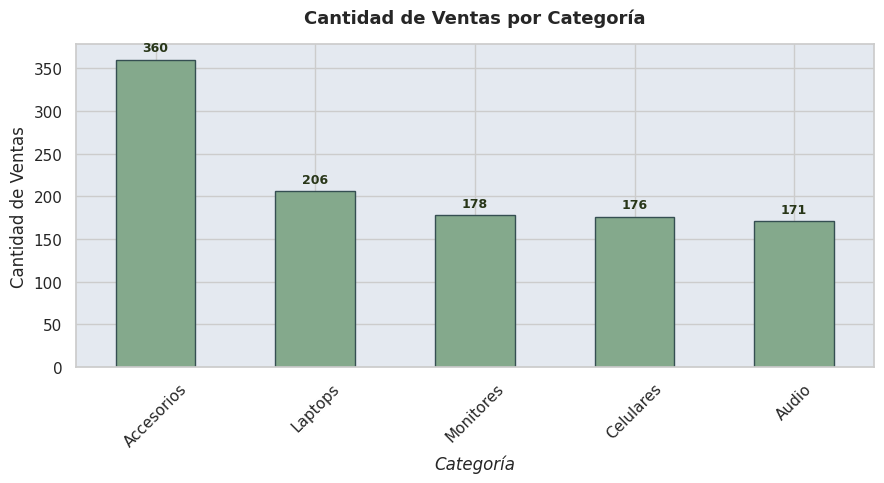

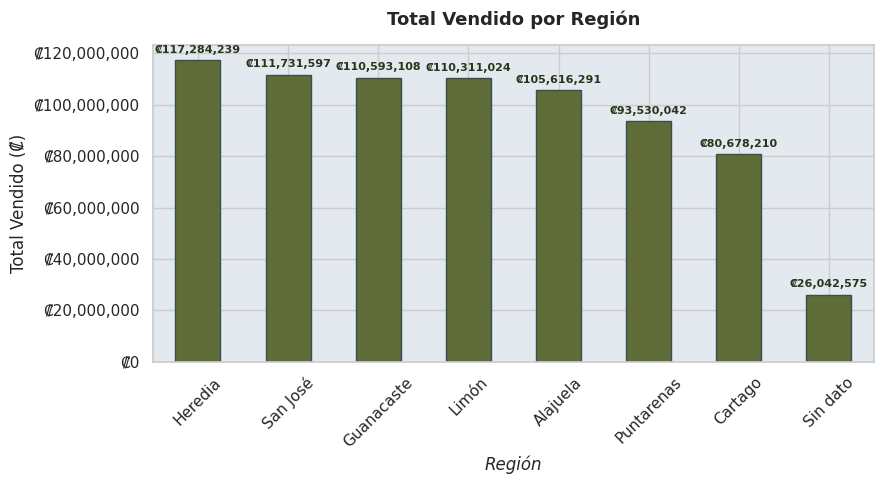

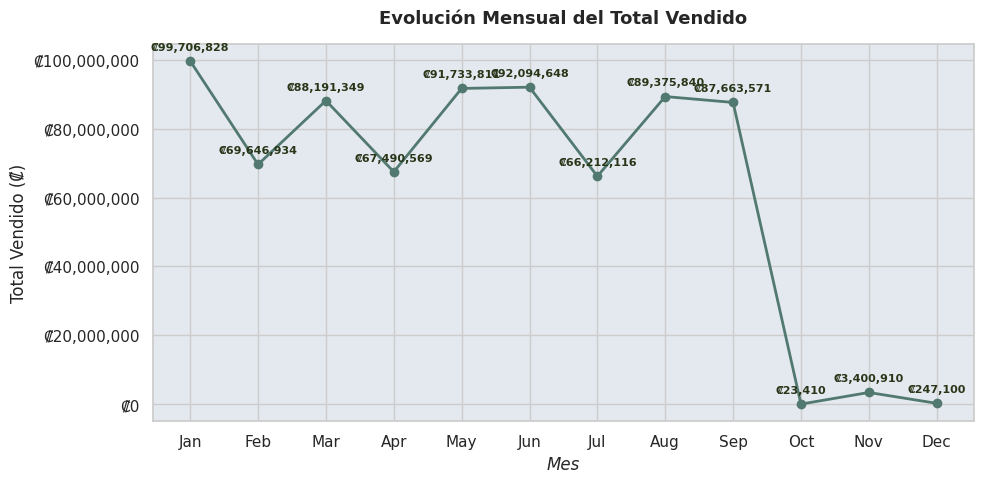

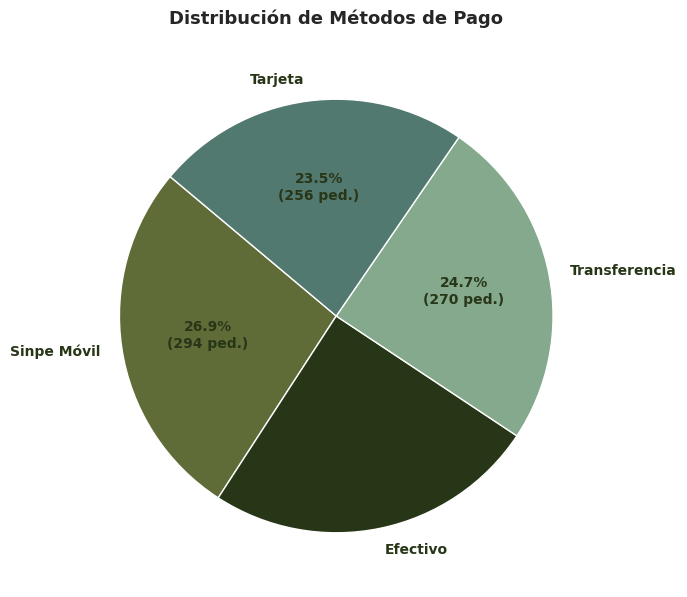

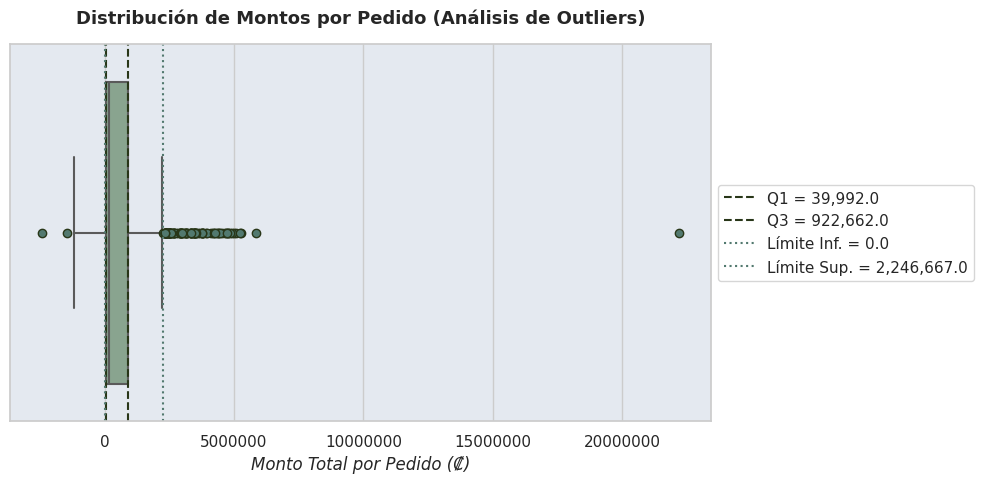

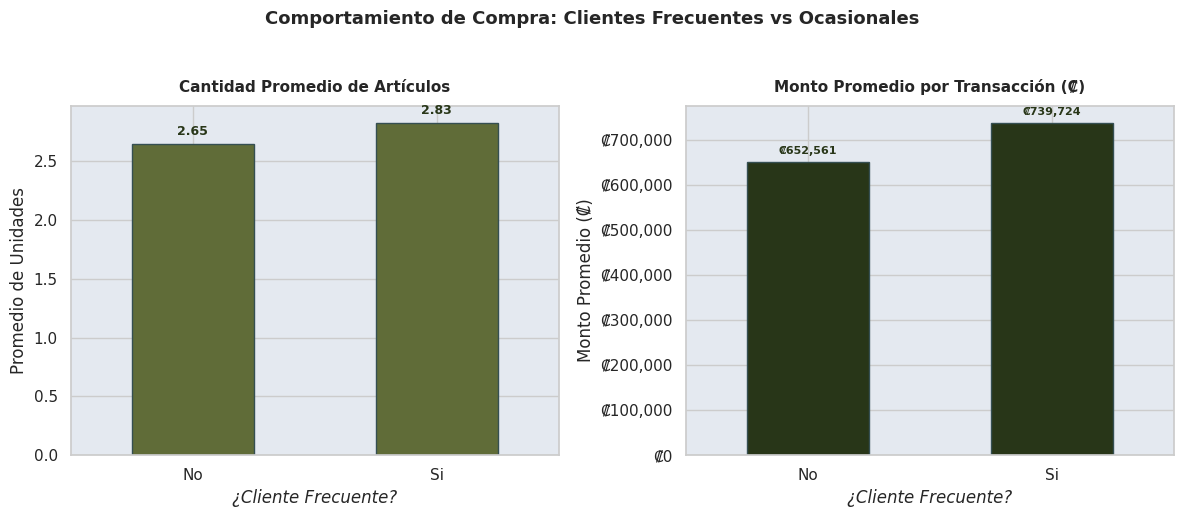


PROYECTO FINAL - ANALISIS DE VENTAS
1. Cargar archivo CSV
2. Mostrar informacion del conjunto de datos
3. Mostrar primeras y ultimas filas
4. Analizar tipos de datos
5. Analizar valores nulos
6. Analizar datos duplicados
7. Obtener estadisticas descriptivas
8. Limpiar datos
9. Filtrar o consultar datos
10. Realizar agrupaciones y operaciones
11. Analizar relaciones entre variables
12. Generar representaciones graficas
13. Resumen y análisis adicional (con datos limpios)
14. Ingresar nuevos datos (submenu)
15. Descargar README.md
16. Salir
Elige una opcion: 13

************************************************************
           ANÁLISIS DE NEGOCIO          
************************************************************
[*] Total de transacciones válidas analizadas: 1,091
[*] Facturación total acumulada: ₡755,787,086.00
[*] Ticket promedio: ₡692,747.10  |  Ticket mediana: ₡175,402.00
[*] Coeficiente de variación del ticket: 174.2%
[*] Categoría líder: Laptops (58.3% de la facturación)

In [18]:
def ejecutar_programa():
    df = None
    df_limpio = None
    nuevos_registros = []

    while True:
        mostrar_menu()
        opcion = input("Elige una opcion: ").strip()

        if opcion == '1':
            df = cargar_csv()
            df_limpio = None  # Se resetea si se carga un archivo nuevo
        elif opcion == '14':
            submenu_ingreso(nuevos_registros,df)
        elif opcion == '15':
            generar_y_descargar_readme()
        elif opcion == '16':
            print("Saliendo del programa. Hasta pronto.")
            break
        else:
            # Validación global: ¿hay datos?
            if not datos_disponibles(df):
                continue

            # Opciones de exploración básica
            if opcion == '2': analizar_tipos_datos(df)
            elif opcion == '3': mostrar_estructura(df)
            elif opcion == '4': analizar_tipos_datos(df)
            elif opcion == '5': analizar_nulos(df)
            elif opcion == '6': analizar_duplicados(df)
            elif opcion == '7': estadisticas_descriptivas(df_limpio if df_limpio is not None else df)

            # Limpieza
            elif opcion == '8':
                df_limpio = analisis_adicional(df)

            # Relaciones
            elif opcion == '11':
                analisis_relaciones(df_limpio if df_limpio is not None else df)

            # Opciones 9, 10 y 12: Requieren datos limpios
            elif opcion in ['9', '10', '12', '13']:
                if df_limpio is None:
                    print("\n[!] No se puede ejecutar esta opcion. Por favor, ejecute la opcion 8 (Limpiar datos) primero para estandarizar el dataset.")
                else:
                    if opcion == '9': filtrar_datos(df_limpio)
                    elif opcion == '10': agrupaciones(df_limpio)
                    elif opcion == '12': generar_graficos(df_limpio)
                    elif opcion == '13': resumen_ejecutivo_negocio(df_limpio)

            else:
                print("Opcion no valida. Por favor elige un numero del 1 al 15.")

ejecutar_programa()